In [1]:
import os

for f in os.listdir():
    if f.endswith(".h5"):
        print(f)

best_pcb_segmentation.h5
pcb_segmentation_model.h5


In [2]:
import sys
print(sys.executable)

c:\Users\Mong\miniconda3\envs\tf_gpu_pd\python.exe


In [3]:
import tensorflow as tf
import cv2
import numpy as np
import sklearn

print("TensorFlow:", tf.__version__)
print("OpenCV:", cv2.__version__)
print("NumPy:", np.__version__)

TensorFlow: 2.10.1
OpenCV: 4.8.1
NumPy: 1.26.4


In [4]:
import sys

print(sys.executable)

c:\Users\Mong\miniconda3\envs\tf_gpu_pd\python.exe


In [5]:
import tensorflow as tf

print(tf.__version__)

2.10.1


In [6]:
!pip install opencv-python

In [7]:
import sys

print(sys.executable)

c:\Users\Mong\miniconda3\envs\tf_gpu_pd\python.exe


In [8]:
import tensorflow as tf

print(tf.__version__)

2.10.1


In [9]:
import cv2
print(cv2.__version__)

4.8.1


In [10]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.10.1
GPUs: []


In [11]:
import os
import json

DATASET_PATH = r"C:\Users\Mong\Desktop\PD_NEW\1\SolDef_AI"

json_files = []

for root, dirs, files in os.walk(DATASET_PATH):
    for f in files:
        if f.endswith(".json"):
            json_files.append(os.path.join(root, f))

print("JSON files found:", len(json_files))
print(json_files[:3])

JSON files found: 428
['C:\\Users\\Mong\\Desktop\\PD_NEW\\1\\SolDef_AI\\Labeled\\WIN_20220329_14_30_32_Pro.json', 'C:\\Users\\Mong\\Desktop\\PD_NEW\\1\\SolDef_AI\\Labeled\\WIN_20220329_14_30_42_Pro.json', 'C:\\Users\\Mong\\Desktop\\PD_NEW\\1\\SolDef_AI\\Labeled\\WIN_20220329_14_30_48_Pro.json']


In [12]:
with open(json_files[0], "r") as f:
    data = json.load(f)

print(data.keys())

dict_keys(['version', 'flags', 'shapes', 'imagePath', 'imageData', 'imageHeight', 'imageWidth'])


In [13]:
print(data["shapes"][0])

{'label': 'no_good', 'points': [[677.3584905660377, 458.0754716981131], [1024.5283018867924, 463.7358490566038], [1024.5283018867924, 510.90566037735846], [1326.4150943396226, 510.90566037735846], [1324.5283018867924, 465.62264150943395], [1677.3584905660377, 465.62264150943395], [1675.4716981132074, 816.566037735849], [1601.8867924528302, 816.566037735849], [1575.4716981132074, 826.0], [1507.5471698113206, 833.5471698113207], [1460.377358490566, 854.3018867924527], [1447.1698113207547, 861.8490566037735], [898.1132075471697, 861.8490566037735], [875.4716981132075, 846.754716981132], [850.9433962264151, 831.6603773584906], [830.188679245283, 822.2264150943396], [803.7735849056603, 816.566037735849], [769.8113207547169, 816.566037735849], [735.8490566037735, 816.566037735849], [677.3584905660377, 814.6792452830189]], 'group_id': None, 'shape_type': 'polygon', 'flags': {}}


In [14]:
for shape in data["shapes"][:5]:
    print(shape)

{'label': 'no_good', 'points': [[677.3584905660377, 458.0754716981131], [1024.5283018867924, 463.7358490566038], [1024.5283018867924, 510.90566037735846], [1326.4150943396226, 510.90566037735846], [1324.5283018867924, 465.62264150943395], [1677.3584905660377, 465.62264150943395], [1675.4716981132074, 816.566037735849], [1601.8867924528302, 816.566037735849], [1575.4716981132074, 826.0], [1507.5471698113206, 833.5471698113207], [1460.377358490566, 854.3018867924527], [1447.1698113207547, 861.8490566037735], [898.1132075471697, 861.8490566037735], [875.4716981132075, 846.754716981132], [850.9433962264151, 831.6603773584906], [830.188679245283, 822.2264150943396], [803.7735849056603, 816.566037735849], [769.8113207547169, 816.566037735849], [735.8490566037735, 816.566037735849], [677.3584905660377, 814.6792452830189]], 'group_id': None, 'shape_type': 'polygon', 'flags': {}}


In [15]:
IMAGE_SIZE = 256
BATCH_SIZE = 8
EPOCHS = 50
LEARNING_RATE = 0.0001

In [16]:
img_path = data["imagePath"]

In [17]:
import os
import json

DATASET_PATH = r"C:\Users\Mong\Desktop\PD_NEW\1\SolDef_AI"

json_files = []

for root, dirs, files in os.walk(DATASET_PATH):
    for f in files:
        if f.endswith(".json"):
            json_files.append(os.path.join(root, f))

all_labels = set()

for json_path in json_files:

    with open(json_path, "r") as f:
        data = json.load(f)

    for shape in data["shapes"]:
        all_labels.add(shape["label"])

print("Classes found:")
print(sorted(all_labels))

Classes found:
['exc_solder', 'good', 'no_good', 'poor_solder', 'spike']


In [18]:
CLASS_MAP = {
    "good": 0,
    "exc_solder": 1,
    "no_good": 2,
    "poor_solder": 3,
    "spike": 4
}

NUM_CLASSES = 5

In [19]:
IMG_SIZE = 256
BATCH_SIZE = 8
EPOCHS = 50
LEARNING_RATE = 0.0001
NUM_CLASSES = 5

In [20]:
import numpy as np
import cv2
import json

In [21]:
CLASS_MAP = {
    "good": 0,
    "exc_solder": 1,
    "no_good": 2,
    "poor_solder": 3,
    "spike": 4
}

In [22]:
with open(json_files[0], "r") as f:
    data = json.load(f)

h = data["imageHeight"]
w = data["imageWidth"]

In [23]:
mask = np.zeros((h, w), dtype=np.uint8)

for shape in data["shapes"]:

    label = shape["label"]

    if label not in CLASS_MAP:
        continue

    class_id = CLASS_MAP[label]

    pts = np.array(
        shape["points"],
        dtype=np.int32
    )

    cv2.fillPoly(
        mask,
        [pts],
        class_id
    )

print(mask.shape)
print(np.unique(mask))

(1440, 2560)
[0 2]


In [24]:
import os
import json
import cv2
import numpy as np

CLASS_MAP = {
    "good": 0,
    "exc_solder": 1,
    "no_good": 2,
    "poor_solder": 3,
    "spike": 4
}

IMG_SIZE = 256

images = []
masks = []

for json_path in json_files:

    with open(json_path, "r") as f:
        data = json.load(f)

    image_path = os.path.join(
        os.path.dirname(json_path),
        data["imagePath"]
    )

    if not os.path.exists(image_path):
        continue

    image = cv2.imread(image_path)

    if image is None:
        continue

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    h = data["imageHeight"]
    w = data["imageWidth"]

    mask = np.zeros((h, w), dtype=np.uint8)

    for shape in data["shapes"]:

        label = shape["label"]

        if label not in CLASS_MAP:
            continue

        class_id = CLASS_MAP[label]

        pts = np.array(
            shape["points"],
            dtype=np.int32
        )

        cv2.fillPoly(
            mask,
            [pts],
            class_id
        )

    image = cv2.resize(
        image,
        (IMG_SIZE, IMG_SIZE)
    )

    mask = cv2.resize(
        mask,
        (IMG_SIZE, IMG_SIZE),
        interpolation=cv2.INTER_NEAREST
    )

    images.append(image)
    masks.append(mask)

print("Images Loaded:", len(images))
print("Masks Loaded:", len(masks))

Images Loaded: 428
Masks Loaded: 428


In [25]:
X = np.array(images, dtype=np.float32) / 255.0
y = np.array(masks, dtype=np.uint8)

print(X.shape)
print(y.shape)

(428, 256, 256, 3)
(428, 256, 256)


In [26]:
from tensorflow.keras.utils import to_categorical

NUM_CLASSES = 5

y_cat = to_categorical(
    y,
    num_classes=NUM_CLASSES
)

print(y_cat.shape)

(428, 256, 256, 5)


In [27]:
from sklearn.model_selection import train_test_split

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y_cat,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_val.shape)

(342, 256, 256, 3)
(86, 256, 256, 3)


In [29]:
from tensorflow.keras import layers
from tensorflow.keras.models import Model

inputs = layers.Input((256,256,3))

# Encoder
c1 = layers.Conv2D(32,3,activation='relu',padding='same')(inputs)
c1 = layers.Conv2D(32,3,activation='relu',padding='same')(c1)
p1 = layers.MaxPooling2D()(c1)

c2 = layers.Conv2D(64,3,activation='relu',padding='same')(p1)
c2 = layers.Conv2D(64,3,activation='relu',padding='same')(c2)
p2 = layers.MaxPooling2D()(c2)

# Bottleneck
bn = layers.Conv2D(128,3,activation='relu',padding='same')(p2)
bn = layers.Conv2D(128,3,activation='relu',padding='same')(bn)

# Decoder
u1 = layers.UpSampling2D()(bn)
u1 = layers.concatenate([u1,c2])

c3 = layers.Conv2D(64,3,activation='relu',padding='same')(u1)
c3 = layers.Conv2D(64,3,activation='relu',padding='same')(c3)

u2 = layers.UpSampling2D()(c3)
u2 = layers.concatenate([u2,c1])

c4 = layers.Conv2D(32,3,activation='relu',padding='same')(u2)
c4 = layers.Conv2D(32,3,activation='relu',padding='same')(c4)

outputs = layers.Conv2D(
    5,
    1,
    activation='softmax'
)(c4)

model = Model(inputs, outputs)

model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 256, 256, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 256, 256, 32  896         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 conv2d_1 (Conv2D)              (None, 256, 256, 32  9248        ['conv2d[0][0]']                 
                                )                                                             

In [30]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [31]:
import tensorflow as tf

print(tf.config.list_physical_devices('GPU'))

[]


In [32]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

callbacks = [

    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        verbose=1
    ),

    ModelCheckpoint(
        'best_pcb_segmentation.h5',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

In [33]:
import numpy as np
print(np.__version__)

1.26.4


In [34]:
import sys
print(sys.executable)

c:\Users\Mong\miniconda3\envs\tf_gpu_pd\python.exe


In [35]:
import sys
print(sys.executable)

import numpy
print("NumPy:", numpy.__version__)

c:\Users\Mong\miniconda3\envs\tf_gpu_pd\python.exe
NumPy: 1.26.4


In [36]:
import tensorflow as tf

print(tf.__version__)
print(tf.config.list_physical_devices('GPU'))

2.10.1
[]


In [37]:
import tensorflow
print(tensorflow.__version__)

2.10.1


In [38]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[]


In [39]:
import numpy as np
import tensorflow as tf

print("NumPy:", np.__version__)
print("TensorFlow:", tf.__version__)

NumPy: 1.26.4
TensorFlow: 2.10.1


In [40]:
import tensorflow as tf

print("TF:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TF: 2.10.1
GPU: []


In [41]:
!nvidia-smi

Wed Jun 10 15:34:57 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 566.07                 Driver Version: 566.07         CUDA Version: 12.7     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3050 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   54C    P8             11W /   35W |       0MiB /   4096MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [42]:
import tensorflow as tf
import numpy as np

print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.10.1
NumPy: 1.26.4
GPU: []


In [43]:
import cv2
import sklearn
import matplotlib

print("OpenCV OK")
print("Scikit-learn OK")
print("Matplotlib OK")

OpenCV OK
Scikit-learn OK
Matplotlib OK


In [44]:
import sys
print(sys.executable)

c:\Users\Mong\miniconda3\envs\tf_gpu_pd\python.exe


In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=2,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
 33/171 [====>.........................] - ETA: 1:40 - loss: 0.9876 - accuracy: 0.8962

In [ ]:
print("Final Training Accuracy:", history.history['accuracy'][-1])

print("Final Validation Accuracy:", history.history['val_accuracy'][-1])

Final Training Accuracy: 0.9617511034011841
Final Validation Accuracy: 0.948205828666687


In [ ]:
history.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy', 'lr'])

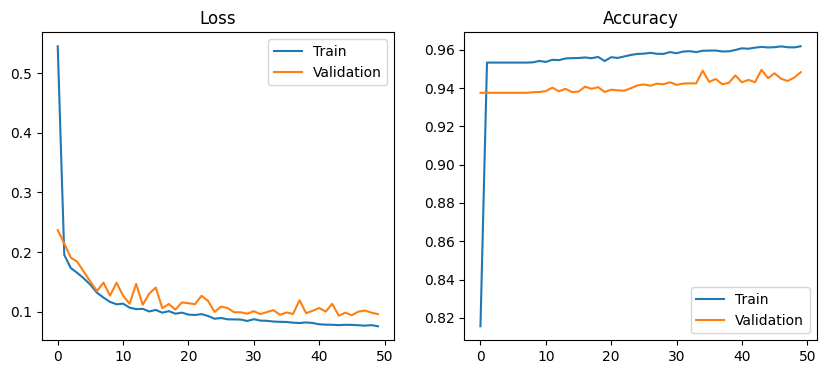

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.legend(['Train','Validation'])

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.legend(['Train','Validation'])

plt.show()

In [ ]:
model.save("pcb_segmentation_model.h5")

In [ ]:
idx = 0

image = X_val[idx]

pred = model.predict(
    np.expand_dims(image, axis=0)
)

pred_mask = np.argmax(pred[0], axis=-1)

1/1 [==============================] - 0s 141ms/step


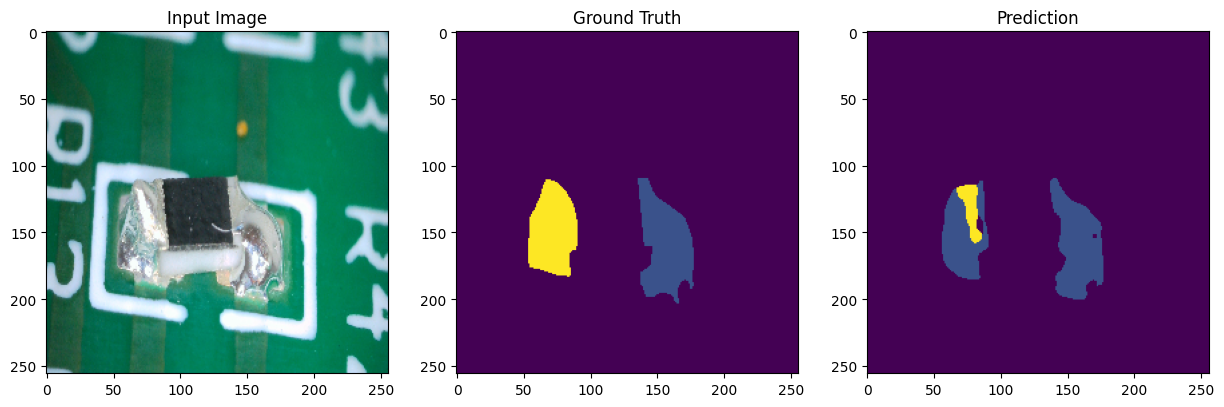

In [ ]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(image)
plt.title("Input Image")

plt.subplot(1,3,2)
plt.imshow(np.argmax(y_val[idx], axis=-1))
plt.title("Ground Truth")

plt.subplot(1,3,3)
plt.imshow(pred_mask)
plt.title("Prediction")

plt.show()

In [ ]:
from sklearn.metrics import jaccard_score

In [ ]:
history.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy', 'lr'])

In [ ]:
model.save("pcb_segmentation_model.h5")

In [ ]:
import os

print(os.getcwd())

c:\Users\Mong\Desktop\Eden\RT-DETR


In [ ]:
pred = model.predict(np.expand_dims(X_val[0], axis=0))
pred_mask = np.argmax(pred[0], axis=-1)

print(np.unique(pred_mask))

1/1 [==============================] - 0s 61ms/step
[0 1 4]


In [ ]:
print(CLASS_MAP)

{'good': 0, 'exc_solder': 1, 'no_good': 2, 'poor_solder': 3, 'spike': 4}


1/1 [==============================] - 0s 59ms/step


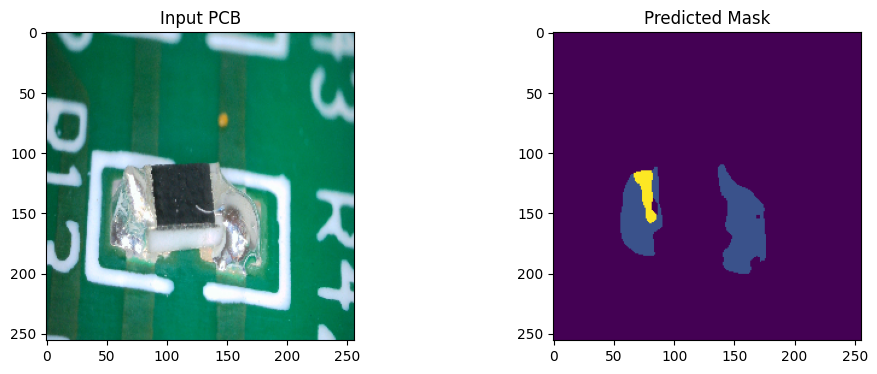

In [ ]:
import matplotlib.pyplot as plt

image = X_val[0]

pred = model.predict(
    np.expand_dims(image, axis=0)
)

pred_mask = np.argmax(
    pred[0],
    axis=-1
)

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Input PCB")

plt.subplot(1,2,2)
plt.imshow(pred_mask)
plt.title("Predicted Mask")

plt.show()

In [ ]:
class_names = {
    1: "exc_solder",
    2: "good",
    3: "no_good",
    4: "poor_solder",
    5: "spike"
}

classes = np.unique(pred_mask)

detected = [
    class_names[c]
    for c in classes
    if c in class_names
]

print(detected)

['exc_solder', 'poor_solder']


##Upload

In [ ]:
from tkinter import Tk
from tkinter.filedialog import askopenfilename

root = Tk()
root.attributes('-topmost', True)
root.withdraw()

image_path = askopenfilename()

print(image_path)

root.destroy()

C:/Users/Mong/Desktop/WIN_20220330_16_35_23_Pro.jpg


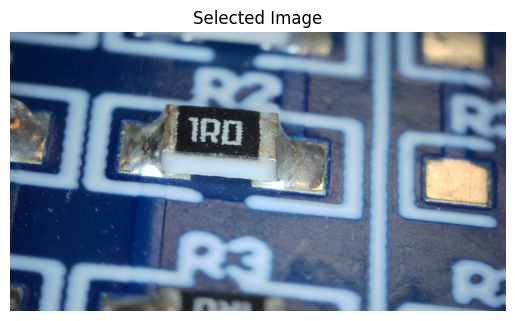

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

IMG_SIZE = 256

img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

original = img.copy()

img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
img = img.astype(np.float32) / 255.0

plt.imshow(original)
plt.title("Selected Image")
plt.axis("off")
plt.show()

In [ ]:
import os

for root, dirs, files in os.walk(r"C:\Users\Mong\Desktop\PD_NEW\1"):
    for file in files:
        if file.endswith(".h5"):
            print(os.path.join(root, file))

In [ ]:
import os

for root, dirs, files in os.walk(r"C:\Users\Mong\Desktop\PD_NEW\1"):
    for file in files:
        if file.endswith(".h5"):
            print(os.path.join(root, file))

In [ ]:
print("history" in globals())

True


In [ ]:
print("X_train" in globals())
print("y_train" in globals())

True
True


In [ ]:
import tensorflow as tf

print(tf.__version__)
print(tf.config.list_physical_devices('GPU'))

2.10.1
[]


In [ ]:
CLASS_NAMES = {
    0: "background",
    1: "exc_solder",
    2: "good",
    3: "no_good",
    4: "poor_solder",
    5: "spike"
}

found = np.unique(pred_mask)

print("\nDetected Classes:")

for c in found:
    if c in CLASS_NAMES:
        print("-", CLASS_NAMES[c])


Detected Classes:
- background
- exc_solder
- poor_solder


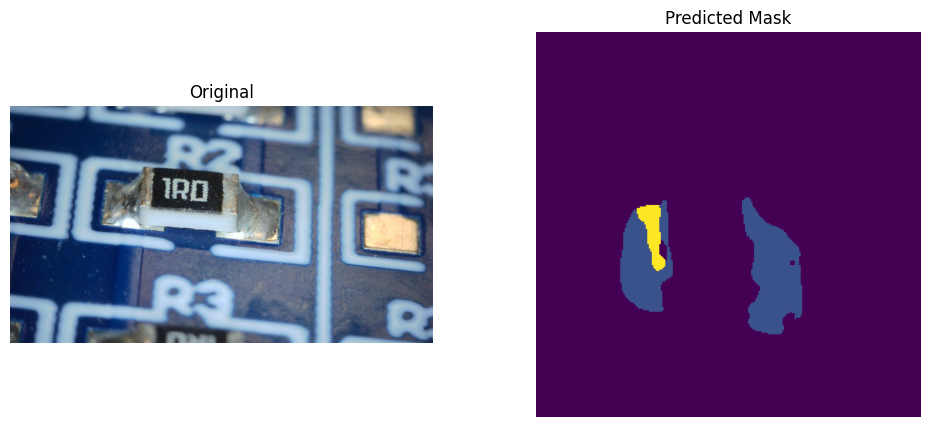

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(original)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(pred_mask)
plt.title("Predicted Mask")
plt.axis("off")

plt.show()

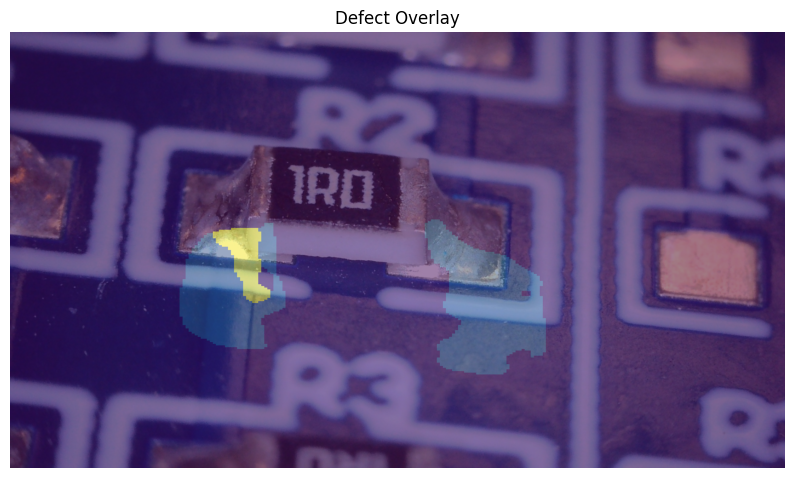

In [ ]:
mask_colored = cv2.resize(
    pred_mask.astype(np.uint8),
    (original.shape[1], original.shape[0]),
    interpolation=cv2.INTER_NEAREST
)

plt.figure(figsize=(10,6))

plt.imshow(original)
plt.imshow(mask_colored, alpha=0.5)

plt.title("Defect Overlay")
plt.axis("off")

plt.show()

In [ ]:
import time

idx = 0

print("Before prediction")

start = time.time()

pred = model.predict(
    np.expand_dims(X_val[idx], axis=0),
    verbose=0
)

end = time.time()

print("After prediction")
print("Time:", end - start)

In [ ]:
idx = 0

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(X_val[idx])
plt.title("Image")

plt.subplot(1,3,2)
plt.imshow(np.argmax(y_val[idx], axis=-1))
plt.title("Ground Truth")

pred = model.predict(
    np.expand_dims(X_val[idx], axis=0),
    verbose=0
)

plt.subplot(1,3,3)
plt.imshow(np.argmax(pred[0], axis=-1))
plt.title("Prediction")

plt.show()

In [ ]:
plt.imshow(mask)
plt.show()